# A. Importation of libraries and Configs

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
class Config:
    # Path to the pseudonimized revenues dataset
    dataset_dir = r"Database\revenues_pseudonymized.xlsx"
    # Path to the enrollee infos
    enrollees_dir = r"Database\enrollees_pseudonymized.xlsx"
    # Path to the machine learning model parameters
    parameters_dir = r"machine_learning\parameters.json"

    # Path to cache directory to store preprocessed dataset if needed
    cache_dir = ""
    load_cache = True

    # Path to store transformer results
    results_dir = r"C:\Users\rjbel\Python\Data\Thesis\Results"


    # The date used
    observation_end = datetime.today()

    # Class to predict
    target_feature = 'dtp_bracket'
    # Test size in %
    test_size = 0.3

    # Time points used in generating survival features
    # It's not until 120 since the earliest pre-payment is 288 days
    time_points = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450]


args = Config()

# B. Loading of datasets

## 1. Revenues

In [3]:
df_revenues = pd.read_excel(args.dataset_dir)

In [4]:
df_revenues

,entry_number,entry_date,due_date,school_year,student_id_pseudonimized,category_name,discount_refund_applied_to,amount_due,amount_paid,account_name,receivables
0,0,2025-10-13,2025-10-13,2014,9XBPS6GQ,Form 137,NaN,150.0,150.0,G-Cash,0.0
1,1,2016-01-01,2016-01-01,2016,QCNXOF71,Back Account,NaN,3524.0,0.0,Not Applicable,3524.0
2,2,2016-01-01,2016-01-01,2016,UFN5RBCA,Back Account,NaN,9831.0,0.0,Not Applicable,9831.0
3,3,2016-01-01,2016-01-01,2016,CATF26JR,Back Account,NaN,9240.0,0.0,Not Applicable,9240.0
4,4,2016-01-01,2016-01-01,2016,TE11Z2LJ,Back Account,NaN,5886.0,0.0,Not Applicable,5886.0
...,...,...,...,...,...,...,...,...,...,...,...
52018,53768,2026-02-27,2026-12-04,2026,HAHX9ZRO,G02-OF-2nd,NaN,5467.0,0.0,Not Applicable,5467.0
52019,53769,2026-02-27,2027-03-05,2026,HAHX9ZRO,G02-OF-3rd,NaN,5466.0,0.0,Not Applicable,5466.0
52020,53770,2026-03-02,2026-03-02,2026,6BOCQ8CS,Reservation Fee - SpEd,NaN,3000.0,3000.0,Bank,0.0
52021,53771,2026-03-03,2026-03-03,2026,878JLWX8,Assesment Fee,NaN,600.0,600.0,Cash,0.0


## 2. Enrollees

In [5]:
df_enrollees = pd.read_excel(args.enrollees_dir)

In [6]:
df_enrollees

,school_year,student_id_pseudonimized,plan_type,grade_level,enrollment_date,education_level,has_refunded
0,2018,08GNGU9D,Plan - D,G03,2018-06-07,Elementary,No Refund
1,2018,0JWX77BI,Plan - B,SpE,2018-06-07,Special Education,No Refund
2,2018,0LZJ7928,Plan - A,G01,2018-05-18,Elementary,No Refund
3,2018,15RI5SWE,Plan - B,G03,2018-06-06,Elementary,No Refund
4,2018,1IGM0VHQ,Plan - A,G01,2018-05-04,Elementary,No Refund
...,...,...,...,...,...,...,...
2701,2026,YHSVJHFT,Plan - C,SpE,2026-01-30,Special Education,No Refund
2702,2026,YMJ3L6X6,Plan - B,G08,2026-01-19,Junior High,No Refund
2703,2026,YNT1UYY7,Plan - A,SpE,2026-01-31,Special Education,No Refund
2704,2026,Z3FMQ7JI,Plan - A,G05,2026-01-09,Elementary,No Refund


## 3. Credit Sales

In [7]:
from feature_engineering.credit_sales_machine_learning import CreditSales

cs = CreditSales(df_revenues, df_enrollees, args)
df_credit_sales = cs.show_data()

Single due date records: 10186
Multiple due date records: 262


In [8]:
df_credit_sales

,school_year,student_id_pseudonimized,category_name,gross_receivables,amount_discounted,adjustments,credit_sale_amount,due_date,date_fully_paid,days_elapsed_until_fully_paid,...,amount_paid_cumsum,opening_balance,plan_type_Plan - A,plan_type_Plan - B,plan_type_Plan - C,plan_type_Plan - D,plan_type_Plan - E,plan_type_nan,dtp_bracket,censor
0,2016,TE11Z2LJ,Back Account,5886.0,0.0,0.0,5886.0,2016-01-01,2019-03-11,1165,...,0.0,5886.0,0.0,0.0,0.0,0.0,0.0,1.0,90_days,1
1,2016,QCNXOF71,Back Account,3524.0,0.0,0.0,3524.0,2016-01-01,2019-01-31,1126,...,0.0,3524.0,0.0,0.0,0.0,0.0,0.0,1.0,90_days,1
2,2016,LI5DFHZ5,Back Account,5650.0,0.0,0.0,5650.0,2016-01-01,2021-01-29,1855,...,0.0,5650.0,0.0,0.0,0.0,0.0,0.0,1.0,90_days,1
3,2016,CATF26JR,Back Account,9240.0,0.0,0.0,9240.0,2016-01-01,2019-02-06,1132,...,0.0,9240.0,0.0,0.0,0.0,0.0,0.0,1.0,90_days,1
4,2016,UFN5RBCA,Back Account,9831.0,0.0,0.0,9831.0,2016-01-01,2019-04-26,1211,...,0.0,9831.0,0.0,0.0,0.0,0.0,0.0,1.0,90_days,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10284,2026,5NX2Y86F,G09-OF-Full,18800.0,0.0,0.0,18800.0,2026-07-11,2026-02-02,-159,...,338521.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,on_time,1
10285,2026,XNTCIHFL,G03-OF-Full,3850.0,0.0,0.0,3850.0,2026-07-11,2026-01-31,-161,...,223810.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,on_time,1
10286,2026,D9L1401L,G06-OF-Full,10000.0,0.0,0.0,10000.0,2026-07-11,2026-01-31,-161,...,230000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,on_time,1
10287,2026,XO7E9JLP,G09-OF-Full,800.0,0.0,0.0,800.0,2026-07-11,2026-01-16,-176,...,345984.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,on_time,1


# C. Exploratory Data Analysis

In [9]:
# Get counts
counts = df_credit_sales.dtp_bracket.value_counts()

# Convert to percentages
percentages = counts / counts.sum() * 100

# Combine into one DataFrame
result = pd.DataFrame({
    'count': counts,
    'percentage': percentages.round(2)
})

print(result)

             count  percentage
dtp_bracket                   
on_time       3818       40.31
30_days       2769       29.24
90_days       1831       19.33
60_days       1053       11.12


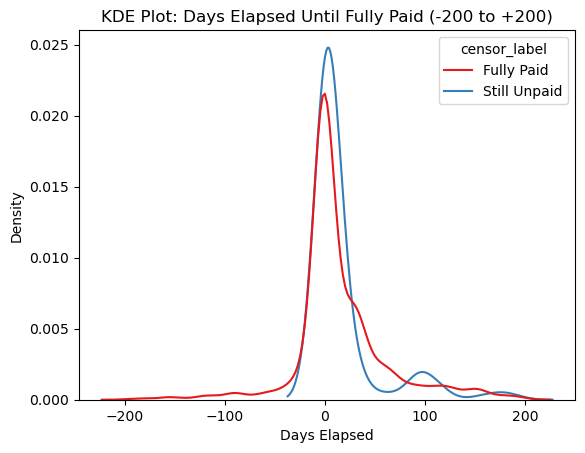

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Remove those that have no full dtp_history:
df_filtered = df_credit_sales.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])


# Clean and filter directly on the DataFrame
df_filtered = df_filtered.loc[
    df_filtered['days_elapsed_until_fully_paid']
        .replace("", np.nan)   # replace empty strings with NaN
        .dropna()              # drop NaNs
        .index                 # keep aligned index
]


# Apply numeric filter
df_filtered = df_filtered[
    (df_filtered['days_elapsed_until_fully_paid'] >= -200) &
    (df_filtered['days_elapsed_until_fully_paid'] <= 200)
]

# Convert censor column to categorical with labels
df_filtered["censor_label"] = (
    df_filtered["censor"]
    .map({0: "Still Unpaid", 1: "Fully Paid"})
    .astype("category")   # force categorical type
)


# KDE plot with grouping by categorical censor labels
sns.kdeplot(
    data=df_filtered,
    x="days_elapsed_until_fully_paid",
    hue="censor_label",
    fill=False,
    common_norm=False,
    palette="Set1"
)

plt.title("KDE Plot: Days Elapsed Until Fully Paid (-200 to +200)")
plt.xlabel("Days Elapsed")
plt.ylabel("Density")
plt.show()

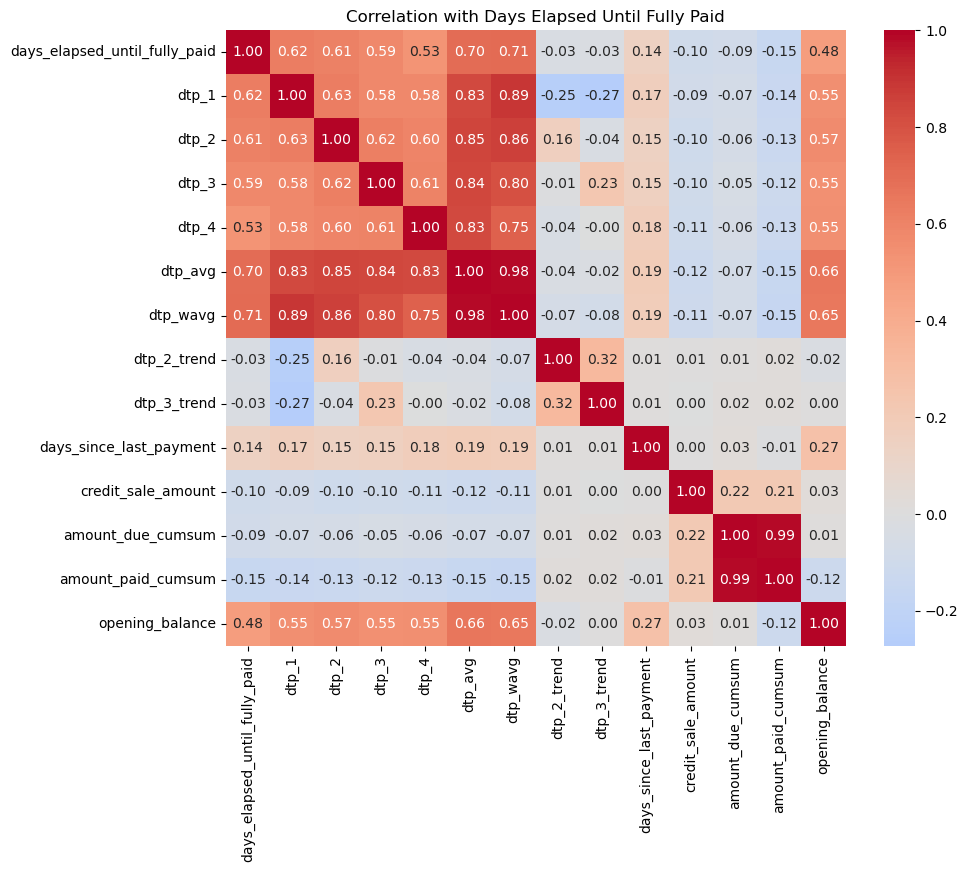

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df_credit_sales[df_credit_sales['censor'] == 1]
df_filtered = df_filtered.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])

# Select relevant columns
cols = ['days_elapsed_until_fully_paid', 
        'dtp_1', 'dtp_2', 'dtp_3', 'dtp_4', 
        'dtp_avg', 'dtp_wavg', 'dtp_2_trend',
        'dtp_3_trend', 'days_since_last_payment',
        'credit_sale_amount', 'amount_due_cumsum',
        'amount_paid_cumsum', 'opening_balance']

# Compute correlation matrix
corr = df_filtered[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation with Days Elapsed Until Fully Paid")
plt.show()

# D. Machine Learning Pipelines

## 1. Survival Analysis Sandbox

### a. Step by step pipeline

In [12]:
# Helper columns
drop_columns = ['school_year', 'student_id_pseudonimized', 'category_name',
       'gross_receivables', 'amount_discounted', 'adjustments', 'due_date_prev_1',
       'due_date_prev_2', 'date_fully_paid', 'last_payment_date']

# Plan related columns
drop_columns = drop_columns + ['plan_type_Plan - A', 'plan_type_Plan - B', 'plan_type_Plan - C',
                               'plan_type_Plan - D', 'plan_type_Plan - E', 'plan_type_nan']

df_data = df_credit_sales[df_credit_sales['censor'] == 1]

df_data = df_data.drop(columns=drop_columns)
df_data.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'], inplace=True)
df_data

,credit_sale_amount,due_date,days_elapsed_until_fully_paid,dtp_1,dtp_2,dtp_3,dtp_4,dtp_avg,dtp_wavg,dtp_2_trend,dtp_3_trend,days_since_last_payment,amount_due_cumsum,amount_paid_cumsum,opening_balance,dtp_bracket,censor
77,2700.0,2018-06-04,365,365,365,365,365,365.0,365.0,0.000000,0.000000,-1,39594.0,5000.0,34594.0,90_days,1
78,11580.0,2018-06-04,365,365,365,365,365,365.0,365.0,0.000000,0.000000,-1,39594.0,5000.0,34594.0,90_days,1
79,4500.0,2018-06-04,365,365,365,365,365,365.0,365.0,0.000000,0.000000,-1,39594.0,5000.0,34594.0,90_days,1
82,2700.0,2018-06-04,365,365,365,365,519,403.5,380.4,0.000000,0.000000,-1,39594.0,5000.0,34594.0,90_days,1
114,4500.0,2018-06-15,344,344,276,344,344,327.0,323.6,0.000000,0.000000,15,31002.0,8395.0,22607.0,90_days,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,5360.0,2026-03-31,-288,-38,-10,-4,-4,-14.0,-19.4,1.120000,0.641509,40,112220.0,132807.0,0.0,on_time,1
10279,8300.0,2026-07-11,-162,293,1,260,30,146.0,172.5,-0.555133,-0.031309,145,266474.0,266474.0,0.0,on_time,1
10284,18800.0,2026-07-11,-159,0,130,-51,204,70.75,49.2,0.179558,-0.042079,164,338521.0,338521.0,0.0,on_time,1
10285,3850.0,2026-07-11,-161,-3,-3,2,3,-0.25,-1.4,0.000000,0.005285,161,223810.0,223810.0,0.0,on_time,1


In [13]:
drop_columns = ['school_year', 'student_id_pseudonimized', 'category_name',
       'gross_receivables', 'amount_discounted', 'adjustments', 'due_date',
       'due_date_prev_1', 'due_date_prev_2', 'date_fully_paid', 'last_payment_date',
       'plan_type_Plan - D', 'plan_type_Plan - E', 'plan_type_nan', 'dtp_bracket']

drop_columns = drop_columns + ['plan_type_Plan - A', 'plan_type_Plan - B', 'plan_type_Plan - C']

df_data_surv = df_credit_sales.drop(columns=drop_columns)
df_data_surv.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'], inplace=True)
df_data_surv

,credit_sale_amount,days_elapsed_until_fully_paid,dtp_1,dtp_2,dtp_3,dtp_4,dtp_avg,dtp_wavg,dtp_2_trend,dtp_3_trend,days_since_last_payment,amount_due_cumsum,amount_paid_cumsum,opening_balance,censor
77,2700.0,365,365,365,365,365,365.0,365.0,0.000000,0.000000,-1,39594.0,5000.0,34594.0,1
78,11580.0,365,365,365,365,365,365.0,365.0,0.000000,0.000000,-1,39594.0,5000.0,34594.0,1
79,4500.0,365,365,365,365,365,365.0,365.0,0.000000,0.000000,-1,39594.0,5000.0,34594.0,1
82,2700.0,365,365,365,365,519,403.5,380.4,0.000000,0.000000,-1,39594.0,5000.0,34594.0,1
114,4500.0,344,344,276,344,344,327.0,323.6,0.000000,0.000000,15,31002.0,8395.0,22607.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,5360.0,-288,-38,-10,-4,-4,-14.0,-19.4,1.120000,0.641509,40,112220.0,132807.0,0.0,1
10279,8300.0,-162,293,1,260,30,146.0,172.5,-0.555133,-0.031309,145,266474.0,266474.0,0.0,1
10284,18800.0,-159,0,130,-51,204,70.75,49.2,0.179558,-0.042079,164,338521.0,338521.0,0.0,1
10285,3850.0,-161,-3,-3,2,3,-0.25,-1.4,0.000000,0.005285,161,223810.0,223810.0,0.0,1


In [14]:
df_surv = df_data_surv.copy()

X = df_surv.drop(columns=['days_elapsed_until_fully_paid', 'censor'])
T = df_surv['days_elapsed_until_fully_paid']
E = df_surv['censor']

# Avoid negative values by shifting by the days of pre-paid period
earliest_payment = np.minimum(T, 0) # Maximum to only get pre-payments
ε = 1e-6 # Used to avoid zero values
T = T - earliest_payment + ε

In [15]:
earliest_payment

77         0
78         0
79         0
82         0
114        0
        ... 
10275   -288
10279   -162
10284   -159
10285   -161
10287   -176
Name: days_elapsed_until_fully_paid, Length: 6289, dtype: int64

In [16]:
import xgboost as xgb
print(xgb.build_info())  # Should show cuda_version if GPU-enabled

{'BUILTIN_PREFETCH_PRESENT': False, 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'USE_CUDA': False, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'c:\\Users\\rjbel\\anaconda3\\envs\\Thesis_IPPP_backup\\Library\\bin\\xgboost.dll'}


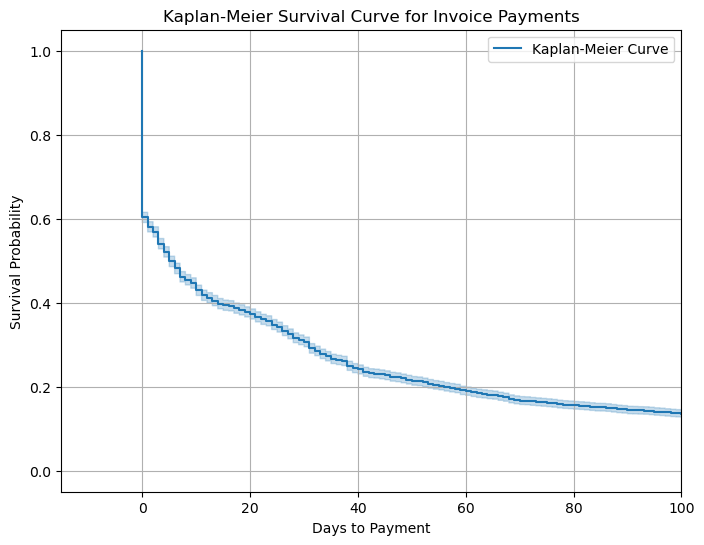

In [17]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# ============================================
# STEP X — Plot Kaplan-Meier Survival Curve
# ============================================

# Initialize Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Fit the model on your training data
kmf.fit(durations=T,
        event_observed=E,
        label="Kaplan-Meier Curve")

# Plot the survival function
plt.figure(figsize=(8,6))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve for Invoice Payments")
plt.xlabel("Days to Payment")
plt.ylabel("Survival Probability")
plt.xlim(-15, 100)
plt.grid(True)
plt.show()

In [18]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from lifelines import CoxPHFitter

# ============================================
# STEP 0 — Prepare Survival Data
# ============================================
survival_train = np.array(
    [(bool(e), float(t)) for e, t in zip(E.values, T.values)],
    dtype=[('event', 'bool'), ('time', 'float')]
)

# ============================================
# STEP 1 — Preprocess Predictors
# ============================================
# Drop highly correlated features (>0.95)
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_reduced = X.drop(columns=to_drop)

# Standardize predictors
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_reduced), columns=X_reduced.columns)

# ============================================
# STEP 2 — Hyperparameter Grids
# ============================================
coxnet_params = {
    "l1_ratio": [0.2, 0.5, 0.8, 1.0],
    "alphas": [[1e-6], [1e-5], [1e-4], [1e-3], [1e-2]]
}

coxph_params = {
    "penalizer": [0.01, 0.1, 1, 10, 100],
    "baseline_estimation_method": ["breslow"]  # ✅ only use breslow for stability
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ============================================
# STEP 3 — CoxnetSurvivalAnalysis Tuning
# ============================================
best_c_index, best_params = -np.inf, None

for l1 in coxnet_params["l1_ratio"]:
    for alpha in coxnet_params["alphas"]:
        c_indices = []
        for train_idx, val_idx in kf.split(X_scaled):
            X_train, X_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
            y_train, y_val = survival_train[train_idx], survival_train[val_idx]

            model = CoxnetSurvivalAnalysis(l1_ratio=l1, alphas=alpha, max_iter=10000, tol=1e-7)

            # ✅ Suppress "all coefficients are zero" warning
            with warnings.catch_warnings():
                warnings.filterwarnings(
                    "ignore",
                    message="all coefficients are zero, consider decreasing alpha",
                    category=UserWarning
                )
                model.fit(X_train, y_train)

            risk_scores = model.predict(X_val)
            c_index = concordance_index_censored(
                y_val["event"], y_val["time"], risk_scores
            )[0]
            c_indices.append(c_index)

        mean_c_index = np.mean(c_indices)
        if mean_c_index > best_c_index:
            best_c_index = mean_c_index
            best_params = {"l1_ratio": l1, "alphas": alpha}

print("Best Coxnet Params:", best_params, "Best C-index:", best_c_index)

# ============================================
# STEP 4 — CoxPHFitter Tuning
# ============================================
best_c_index_ph, best_params_ph = -np.inf, None

for penalizer in coxph_params["penalizer"]:
    for method in coxph_params["baseline_estimation_method"]:
        c_indices = []
        for train_idx, val_idx in kf.split(X_scaled):
            X_train, X_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
            y_train, y_val = survival_train[train_idx], survival_train[val_idx]

            df_train = X_train.copy()
            df_train["time"] = y_train["time"]
            df_train["event"] = y_train["event"]

            df_val = X_val.copy()
            df_val["time"] = y_val["time"]
            df_val["event"] = y_val["event"]

            try:
                cph = CoxPHFitter(penalizer=penalizer, baseline_estimation_method=method)
                cph.fit(df_train, duration_col="time", event_col="event", robust=True)

                risk_scores = cph.predict_partial_hazard(df_val)
                c_index = concordance_index_censored(
                    y_val["event"], y_val["time"], risk_scores.values
                )[0]
                c_indices.append(c_index)

            except Exception as e:
                print(f"Skipped penalizer={penalizer}, method={method} due to error: {e}")
                continue

        if c_indices:  # only update if successful
            mean_c_index = np.mean(c_indices)
            if mean_c_index > best_c_index_ph:
                best_c_index_ph = mean_c_index
                best_params_ph = {"penalizer": penalizer, "baseline_estimation_method": method}

print("Best CoxPHFitter Params:", best_params_ph, "Best C-index:", best_c_index_ph)

Best Coxnet Params: {'l1_ratio': 1.0, 'alphas': [0.01]} Best C-index: 0.7650820213958723
Best CoxPHFitter Params: {'penalizer': 0.01, 'baseline_estimation_method': 'breslow'} Best C-index: 0.7656708011456819


In [19]:
from machine_learning.utils.data.data_preparation import DataPreparer

preparer = DataPreparer(
    df_data,
    target_feature=args.target_feature,
    test_size=args.test_size
)
preparer.prep_data()

X_train = preparer.X_train
X_test = preparer.X_test
y_train = preparer.y_train
y_test = preparer.y_test

c:\Users\rjbel\anaconda3\envs\Thesis_IPPP_backup\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Partitioning datasets based on due_date...
Applying smote...


In [23]:
from machine_learning.utils.features.generate_survival_features import generate_survival_features

best_params = {
    'penalizer': 0.1,
    'l1_ratio': 1,
    'baseline_estimation_method': 'breslow',
    'robust': True,
    'step_size': 0.5
  }

df_survival_train, df_survival_test = generate_survival_features(df_data_surv, T, E, X_train, X_test, best_params, time_points=args.time_points)

In [24]:
parameters = {
    "learning_rate": 0.1,
    "n_estimators": 50,
    "random_state": 42
}

In [25]:
from machine_learning.utils.data.data_preparation import DataPreparer 
from machine_learning import AdaBoostPipeline

preparer = DataPreparer(df_data, args.target_feature, test_size=args.test_size, verbose=False)
preparer.prep_data(balance_strategy="borderline_smote")

X_train, X_test = preparer.X_train, preparer.X_test
y_train, y_test = preparer.y_train, preparer.y_test

pipeline = AdaBoostPipeline(
    X_train, X_test, y_train, y_test,
    args,
    parameters
)

# Capture results from pipeline
result = pipeline.initialize_model().fit(use_feature_selection=True).evaluate().show_results()
result

{'accuracy': 0.07751511819681144,
 'precision_macro': 0.05875,
 'recall_macro': 0.25,
 'f1_macro': 0.0951417004048583,
 'roc_auc_macro': 0.5370114609655129,
 'confusion_matrix': [[0, 171, 323, 0],
  [0, 0, 136, 0],
  [0, 0, 141, 0],
  [0, 1048, 0, 0]],
 'roc_curve': {'0': {'fpr': [0.0, 0.870188679245283, 1.0],
   'tpr': [0.0, 1.0, 1.0]},
  '1': {'fpr': [0.0, 0.7243018419489008, 1.0], 'tpr': [0.0, 0.0, 1.0]},
  '2': {'fpr': [0.0, 0.2735399284862932, 1.0], 'tpr': [0.0, 1.0, 1.0]},
  '3': {'fpr': [0.0, 0.0, 1.0], 'tpr': [0.0, 0.16412213740458015, 1.0]}},
 'pr_curve': {'0': {'precision': [0.2715777899945025,
    0.29993928354584093,
    1.0],
   'recall': [1.0, 1.0, 0.0]},
  '1': {'precision': [0.07476635514018691, 0.0, 1.0],
   'recall': [1.0, 0.0, 0.0]},
  '2': {'precision': [0.07751511819681144, 0.235, 1.0],
   'recall': [1.0, 1.0, 0.0]},
  '3': {'precision': [0.5761407366684992, 1.0, 1.0],
   'recall': [1.0, 0.16412213740458015, 0.0]}}}

In [26]:
from machine_learning.utils.data.data_preparation import DataPreparer
from machine_learning import AdaBoostPipeline

pipeline = AdaBoostPipeline(
    df_survival_train, df_survival_test, y_train, y_test,
    args,
    parameters
)

# Capture results from pipeline
result = pipeline.initialize_model().fit(use_feature_selection=True).evaluate().show_results()
result

{'accuracy': 0.07751511819681144,
 'precision_macro': 0.056490384615384616,
 'recall_macro': 0.25,
 'f1_macro': 0.09215686274509804,
 'roc_auc_macro': 0.5370061494899637,
 'confusion_matrix': [[0, 147, 347, 0],
  [0, 0, 136, 0],
  [0, 0, 141, 0],
  [0, 1048, 0, 0]],
 'roc_curve': {'0': {'fpr': [0.0, 0.870188679245283, 1.0],
   'tpr': [0.0, 1.0, 1.0]},
  '1': {'fpr': [0.0, 0.7100415923945336, 1.0], 'tpr': [0.0, 0.0, 1.0]},
  '2': {'fpr': [0.0, 0.28784266984505363, 1.0], 'tpr': [0.0, 1.0, 1.0]},
  '3': {'fpr': [0.0, 0.0, 1.0], 'tpr': [0.0, 0.16412213740458015, 1.0]}},
 'pr_curve': {'0': {'precision': [0.2715777899945025,
    0.29993928354584093,
    1.0],
   'recall': [1.0, 1.0, 0.0]},
  '1': {'precision': [0.07476635514018691, 0.0, 1.0],
   'recall': [1.0, 0.0, 0.0]},
  '2': {'precision': [0.07751511819681144, 0.22596153846153846, 1.0],
   'recall': [1.0, 1.0, 0.0]},
  '3': {'precision': [0.5761407366684992, 1.0, 1.0],
   'recall': [1.0, 0.16412213740458015, 0.0]}}}

In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import AdaBoostClassifier
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

from machine_learning.utils.features.generate_survival_features import generate_survival_features

# ============================================
# STEP 0 — Initialize and Prepare Data
# ============================================

# Build survival array
survival_train = np.array(
    [(bool(e), float(t)) for e, t in zip(E.values, T.values)],
    dtype=[('event', 'bool'), ('time', 'float')]
)

# ============================================
# STEP 1 — Tune Survival Model
# ============================================
penalties = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
best_penalty, best_c_index = None, -np.inf

for λ in penalties:
    model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[λ])
    model.fit(X, survival_train)
    risk_scores = model.predict(X)
    c_index = concordance_index_censored(E.astype(bool), T, risk_scores)[0]
    if c_index > best_c_index:
        best_penalty, best_c_index = λ, c_index

print("Best Penalty:", best_penalty, "Best C-index:", best_c_index)

# ============================================
# STEP 2 — Retrain Survival Model
# ============================================
survival_model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[best_penalty])
survival_model.fit(df_data_surv, survival_train)

# ============================================
# STEP 3 — Generate Survival Features
# ============================================
df_survival_train, df_survival_test = generate_survival_features(X, T, E, X_train, X_test, best_penalty, time_points=args.time_points)

# ============================================
# STEP 4 — Train Classifier (baseline vs survival)
# ============================================
# Baseline classifier (raw features, full dataset)
baseline_clf = AdaBoostClassifier(**parameters)
baseline_clf.fit(X_train, y_train)
baseline_pred = baseline_clf.predict(X_test)
baseline_f1 = f1_score(y_test, baseline_pred, average="macro")

# Survival-feature classifier (restricted subset)
clf = AdaBoostClassifier(**parameters)
clf.fit(df_survival_train, y_train)
survival_pred = clf.predict(df_survival_test)
survival_f1 = f1_score(y_test, survival_pred, average="macro")

print("Baseline F1:", baseline_f1)
print("Survival F1:", survival_f1)

# ============================================
# STEP 5 — Feature Selection + Final Classifier
# ============================================
selector = SelectFromModel(clf, prefit=True)
X_train_selected = selector.transform(df_survival_train)
X_test_selected  = selector.transform(df_survival_test)

final_clf = AdaBoostClassifier(**parameters)
final_clf.fit(X_train_selected, y_train)
final_pred = final_clf.predict(X_test_selected)
final_f1 = f1_score(y_test, final_pred, average="macro")

print("Final F1 Score:", final_f1)

Best Penalty: 10 Best C-index: 0.7659484511512923


TypeError: 'int' object is not subscriptable

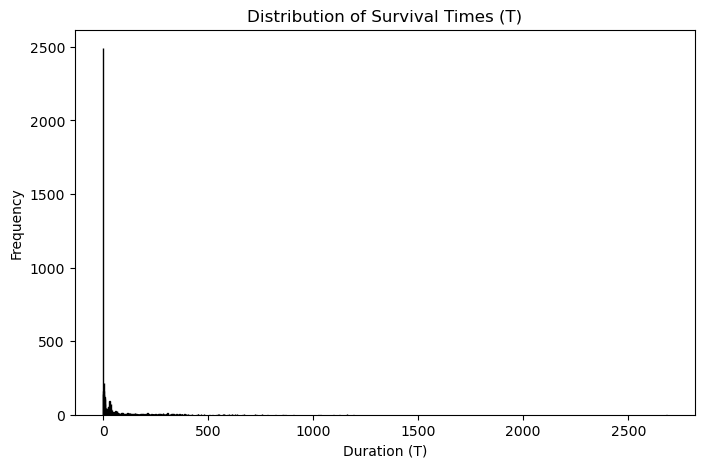

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Count frequency of each unique duration
freq = T.value_counts().sort_index()

# Plot
plt.figure(figsize=(8, 5))
plt.bar(freq.index, freq.values, width=1.0, edgecolor='black')
plt.xlabel("Duration (T)")
plt.ylabel("Frequency")
plt.title("Distribution of Survival Times (T)")
plt.show()

### b. Unedited full pipeline

In [29]:
if False:
    import numpy as np
    from sklearn.metrics import f1_score
    from sklearn.feature_selection import SelectFromModel
    from sklearn.ensemble import RandomForestClassifier
    from sksurv.linear_model import CoxnetSurvivalAnalysis
    from sksurv.metrics import concordance_index_censored

    # ============================================
    # STEP 0 — Prepare Data
    # ============================================
    # X: feature matrix (DataFrame)
    # T: time-to-event (array)
    # E: event indicator (array, 1=event occurred, 0=censored)
    # Y: classification labels (array)

    drop_columns = ['school_year', 'student_id_pseudonimized', 'category_name',
        'gross_receivables', 'amount_discounted', 'adjustments', 'due_date',
        'due_date_prev_1', 'due_date_prev_2', 'date_fully_paid', 'last_payment_date',
        'plan_type_Plan - D', 'plan_type_Plan - E', 'plan_type_nan', 'dtp_bracket']

    drop_columns = drop_columns + ['plan_type_Plan - A', 'plan_type_Plan - B', 'plan_type_Plan - C']

    df_data_surv = df_credit_sales.drop(columns=drop_columns)
    df_data_surv.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'], inplace=True)
    df_data_surv


    X = df_data_surv.drop(columns=['days_elapsed_until_fully_paid', 'censor'])
    T = df_data_surv['days_elapsed_until_fully_paid']
    E = df_data_surv['censor']
    Y = df_data[args.target_feature]

    # Avoid negative values by shifting by the days of pre-paid period
    earliest_pre_payment = np.minimum(T, 0) # Maximum to only get pre-payments
    ε = 1e-6 # Used to avoid zero values
    T = T - earliest_pre_payment + ε



    # Convert to structured array for scikit-survival
    survival_data = np.array([(bool(e), t) for e, t in zip(E, T)],
                            dtype=[('event', 'bool'), ('time', 'float')])

    # ============================================
    # STEP 1 — Define Candidate Penalties
    # ============================================
    penalties = [1e-4, 1e-3, 1e-2, 1e-1, 1]

    best_penalty = None
    best_c_index = -np.inf

    # ============================================
    # STEP 2 — Tune Survival Model
    # ============================================
    for λ in penalties:
        model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[λ])
        model.fit(X, survival_data)
        
        risk_scores = model.predict(X)
        c_index = concordance_index_censored(E.astype(bool), T, risk_scores)[0]
        
        if c_index > best_c_index:
            best_c_index = c_index
            best_penalty = λ

    print("Best Penalty:", best_penalty, "Best C-index:", best_c_index)

    # ============================================
    # STEP 3 — Retrain Survival Model
    # ============================================
    survival_model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[best_penalty])
    survival_model.fit(X, survival_data)

    # ============================================
    # STEP 4 — Generate Survival-Based Features
    # ============================================
    df_survival = generate_survival_features(X, T, E, X_train, X_test, best_penalty)

    # ============================================
    # STEP 5 — Train Initial Classifier
    # ============================================
    clf = RandomForestClassifier(random_state=42)
    clf.fit(df_survival, survival_train)

    # Evaluate initial classifier
    Y_pred_initial = clf.predict(df_survival)
    f1_initial = f1_score(Y, Y_pred_initial, average="macro")
    print("Initial F1 Score:", f1_initial)

    # ============================================
    # STEP 6 — Feature Selection
    # ============================================
    selector = SelectFromModel(clf, prefit=True)
    X_selected = selector.transform(df_survival)

    # ============================================
    # STEP 7 — Train Final Classifier
    # ============================================
    final_clf = RandomForestClassifier(random_state=42)
    final_clf.fit(X_selected, Y)

    # ============================================
    # STEP 8 — Predictions
    # ============================================
    Y_pred_final = final_clf.predict(X_selected)
    f1_final = f1_score(Y, Y_pred_final, average="macro")

    print("Final F1 Score:", f1_final)


## 2. Enhanced with Survival Features

### a. Calculating the best penalty (λ) 

In [30]:
# Helper columns
drop_columns = ['school_year', 'student_id_pseudonimized', 'category_name',
       'gross_receivables', 'amount_discounted', 'adjustments', 'due_date',
       'due_date_prev_1', 'due_date_prev_2', 'date_fully_paid', 'last_payment_date']

# Plan type columns
drop_columns = drop_columns + ['plan_type_Plan - A', 'plan_type_Plan - B', 'plan_type_Plan - C',
                               'plan_type_Plan - D', 'plan_type_Plan - E', 'plan_type_nan']

drop_columns = drop_columns + [args.target_feature]

df_data_surv = df_credit_sales.drop(columns=drop_columns)
df_data_surv.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'], inplace=True)
df_data_surv = df_data_surv[df_data_surv['days_elapsed_until_fully_paid'] > 0]
df_data_surv

,credit_sale_amount,days_elapsed_until_fully_paid,dtp_1,dtp_2,dtp_3,dtp_4,dtp_avg,dtp_wavg,dtp_2_trend,dtp_3_trend,days_since_last_payment,amount_due_cumsum,amount_paid_cumsum,opening_balance,censor
77,2700.0,365,365,365,365,365,365.0,365.0,0.000000,0.000000,-1,39594.0,5000.0,34594.0,1
78,11580.0,365,365,365,365,365,365.0,365.0,0.000000,0.000000,-1,39594.0,5000.0,34594.0,1
79,4500.0,365,365,365,365,365,365.0,365.0,0.000000,0.000000,-1,39594.0,5000.0,34594.0,1
82,2700.0,365,365,365,365,519,403.5,380.4,0.000000,0.000000,-1,39594.0,5000.0,34594.0,1
114,4500.0,344,344,276,344,344,327.0,323.6,0.000000,0.000000,15,31002.0,8395.0,22607.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10243,5267.0,2,-2,8,-9,36,8.25,3.4,0.109890,-0.058824,10,114550.0,109283.0,5267.0,0
10247,967.0,2,10,10,8,-3,6.25,8.3,0.000000,-0.021978,1,184920.0,178753.0,6167.0,0
10249,400.0,2,-1,-1,-4,-5,-2.75,-2.0,0.000000,-0.032967,11,49180.0,80600.0,0.0,0
10254,5800.0,2,11,4,0,0,3.75,5.6,-0.076923,-0.099099,6,118870.0,113070.0,5800.0,0


In [31]:
from sklearn.preprocessing import LabelEncoder

target_feature = args.target_feature

# Extract variables for training the survival model
X = df_data_surv.drop(columns=['days_elapsed_until_fully_paid', 'censor'])
T = df_data_surv['days_elapsed_until_fully_paid']
E = df_data_surv['censor']

# Avoid negative values by shifting by the days of pre-paid period
earliest_pre_payment = np.minimum(T, 0) # Maximum to only get pre-payments
ε = 1e-6 # Used to avoid zero values
T = T - earliest_pre_payment + ε

In [32]:
import numpy as np
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

from machine_learning.utils.features.generate_survival_features import generate_survival_features

# ============================================
# STEP 0 — Initialize and Prepare Data
# ============================================

# Build survival array
survival_train = np.array(
    [(bool(e), float(t)) for e, t in zip(E.values, T.values)],
    dtype=[('event', 'bool'), ('time', 'float')]
)

# ============================================
# STEP 1 — Tune Survival Model
# ============================================
penalties = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
best_penalty, best_c_index = None, -np.inf

for λ in penalties:
    model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[λ], normalize=True)
    model.fit(X, survival_train)
    risk_scores = model.predict(X)
    c_index = concordance_index_censored(E.astype(bool), T, risk_scores)[0]
    if c_index > best_c_index:
        best_penalty, best_c_index = λ, c_index

print(f"Best Penalty: {best_penalty} | Best C-index: {best_c_index}")

# ============================================
# STEP 2 — Retrain Survival Model
# ============================================
survival_model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[best_penalty])
survival_model.fit(X, survival_train)

C:\Users\rjbel\AppData\Local\Temp\ipykernel_9876\1486817708.py:25: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X, survival_train)
C:\Users\rjbel\AppData\Local\Temp\ipykernel_9876\1486817708.py:25: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X, survival_train)
C:\Users\rjbel\AppData\Local\Temp\ipykernel_9876\1486817708.py:25: UserWarning: all coefficients are zero, consider decreasing alpha.
  model.fit(X, survival_train)


Best Penalty: 1e-06 | Best C-index: 0.6722369696969697


,n_alphas,100
,alphas,[1e-06]
,alpha_min_ratio,'auto'
,l1_ratio,1.0
,penalty_factor,None
,normalize,False
,copy_X,True
,tol,1e-07
,max_iter,100000
,verbose,False
,fit_baseline_model,False


In [33]:
best_params = {'penalizer': 0.1,
  'l1_ratio': 1,
  'baseline_estimation_method': 'breslow',
  'robust': True,
  'step_size': 0.5
}

### b. Hyperparameter tuning (various balancing strategies, parameters, and models)

In [34]:
from machine_learning import (
    AdaBoostPipeline,
    DecisionTreePipeline,
    GaussianNaiveBayesPipeline,
    KNearestNeighborPipeline,
    RandomForestPipeline,
    XGBoostPipeline,
    StackedEnsemblePipeline,
    MultiLayerPerceptronPipeline,
    TransformerPipeline,
)

models = {
    #"ada_boost": AdaBoostPipeline,
    #"decision_tree": DecisionTreePipeline,
    #"gaussian_naive_bayes": GaussianNaiveBayesPipeline,
    #"knn": KNearestNeighborPipeline,
    #"random_forest": RandomForestPipeline,
    #"xgboost": XGBoostPipeline,
    "stacked_ensemble": StackedEnsemblePipeline,
    #"nn_mlp": MultiLayerPerceptronPipeline,
    #"nn_rnn": RecurrentNeuralNetworkPipeline,
    #"nn_transformer": TransformerPipeline
}

# Since these models are trained in the GPU, it's best
# to not to parallel compute to avoid bugs
do_not_parallel_compute = ['xg_boost', 'nn_mlp', 'nn_transformer']

In [35]:
from machine_learning.utils.features.generate_thresholds import generate_thresholds

#balance_strategies = ["smote", "borderline_smote", "smoteenn", "smotetomek", "hybrid"]
balance_strategies = ["borderline_smote", "smote_enn", "smote_tomek"]

# thresholds used in the hybrid approach
thresholds = generate_thresholds(min_threshold=0.5, max_threshold=0.9, step=0.1)

In [36]:
# To silence the error when running knn:
# UserWarning: Could not find the number of physical cores for the following reason:
# [WinError 2]
import os

os.environ['OMP_NUM_THREADS'] = '16'

In [37]:
# Older method used to debug if there are any changes in the model's code
if False:
    from MachineLearning.Utils.run_models_single_threaded import run_survival_model_experiments

    df_results = run_survival_model_experiments(df_data_surv, models, balance_strategies, args, best_penalty, thresholds)

In [38]:
# Helper columns
drop_columns = ['school_year', 'student_id_pseudonimized', 'category_name',
       'gross_receivables', 'amount_discounted', 'adjustments', 'due_date_prev_1',
       'due_date_prev_2', 'date_fully_paid', 'last_payment_date']

# Payment plans
#drop_columns = drop_columns + ['plan_type_Plan - A', 'plan_type_Plan - B', 'plan_type_Plan - C',
#                               'plan_type_Plan - D', 'plan_type_Plan - E', 'plan_type_nan']

# Survival related features
drop_columns = drop_columns + ['censor', 'days_elapsed_until_fully_paid']

# Only extract invoices with payments
df_data = df_credit_sales[df_credit_sales['censor'] == 1]

df_data = df_data.drop(columns=drop_columns)

# Drop invoices with missing critical features
df_data.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'], inplace=True)
df_data

,credit_sale_amount,due_date,dtp_1,dtp_2,dtp_3,dtp_4,dtp_avg,dtp_wavg,dtp_2_trend,dtp_3_trend,...,amount_due_cumsum,amount_paid_cumsum,opening_balance,plan_type_Plan - A,plan_type_Plan - B,plan_type_Plan - C,plan_type_Plan - D,plan_type_Plan - E,plan_type_nan,dtp_bracket
77,2700.0,2018-06-04,365,365,365,365,365.0,365.0,0.000000,0.000000,...,39594.0,5000.0,34594.0,0.0,0.0,1.0,0.0,0.0,0.0,90_days
78,11580.0,2018-06-04,365,365,365,365,365.0,365.0,0.000000,0.000000,...,39594.0,5000.0,34594.0,0.0,0.0,1.0,0.0,0.0,0.0,90_days
79,4500.0,2018-06-04,365,365,365,365,365.0,365.0,0.000000,0.000000,...,39594.0,5000.0,34594.0,0.0,0.0,1.0,0.0,0.0,0.0,90_days
82,2700.0,2018-06-04,365,365,365,519,403.5,380.4,0.000000,0.000000,...,39594.0,5000.0,34594.0,0.0,0.0,1.0,0.0,0.0,0.0,90_days
114,4500.0,2018-06-15,344,276,344,344,327.0,323.6,0.000000,0.000000,...,31002.0,8395.0,22607.0,0.0,1.0,0.0,0.0,0.0,0.0,90_days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,5360.0,2026-03-31,-38,-10,-4,-4,-14.0,-19.4,1.120000,0.641509,...,112220.0,132807.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,on_time
10279,8300.0,2026-07-11,293,1,260,30,146.0,172.5,-0.555133,-0.031309,...,266474.0,266474.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,on_time
10284,18800.0,2026-07-11,0,130,-51,204,70.75,49.2,0.179558,-0.042079,...,338521.0,338521.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,on_time
10285,3850.0,2026-07-11,-3,-3,2,3,-0.25,-1.4,0.000000,0.005285,...,223810.0,223810.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,on_time


In [ ]:
from machine_learning.models.stacked_ensemble import StackedEnsemblePipeline
from machine_learning.utils.features.generate_survival_features import generate_survival_features


args = {}

df_surv = df_data_surv.copy()

X = df_surv.drop(columns=['days_elapsed_until_fully_paid', 'censor'])
T = df_surv['days_elapsed_until_fully_paid']
E = df_surv['censor']

# Avoid negative values by shifting by the days of pre-paid period
earliest_payment = np.minimum(T, 0) # Maximum to only get pre-payments
ε = 1e-6 # Used to avoid zero values
T = T - earliest_payment + ε

X_surv_train, X_test_test = generate_survival_features(X, T, E, X_train, X_test, best_params, time_points=[16, 30, 58, 76, 118, 150, 284, 306])


estimators={
    "adaboost":      {"learning_rate": 0.1, "n_estimators": 10},
    "random_forest": {"max_depth": 10, "min_samples_leaf": 1, "n_estimators": 100},
}

sep = StackedEnsemblePipeline(X_surv_train, X_test_test, y_train, y_test, args)
sep.initialize_model(model_parameters=estimators).fit(use_feature_selection=True)

TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'max_depth'

In [ ]:
result_baseline = sep.evaluate().show_results()

In [ ]:
result_baseline

In [ ]:
sep.get_selected_features()

In [ ]:
from machine_learning.utils.training.run_models_parallel import SurvivalExperimentRunner

# Create an experiment runner instance
runner = SurvivalExperimentRunner(
    df_data=df_data,
    df_data_surv=df_data_surv,
    models=models,
    balance_strategies=balance_strategies,
    args=args,
    best_parameters=best_params,
    thresholds=thresholds,
    n_jobs=-1,
    do_not_parallel_compute=do_not_parallel_compute,

    feature_selection_baseline=True,
    feature_selection_enhanced=True
)

# Run experiments
df_results = runner.run()

In [ ]:
df_results

In [ ]:
df_results.sort_values(by='enhanced_accuracy', ascending=False)

In [ ]:
df_results.sort_values(by='enhanced_precision_macro', ascending=False)

In [ ]:
df_results.sort_values(by='enhanced_f1_macro', ascending=False)

In [ ]:
df_results.sort_values(by='enhanced_roc_auc_macro', ascending=False)

In [ ]:
import pandas as pd

# File path
file_path = r"C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\MachineLearning\Results\06 model_results - no feature selection.xlsx"

# Read the Excel file
df = pd.read_excel(file_path)

# Choose which score column to use
score_column = "enhanced_roc_auc_macro"   # <-- change this to the metric you want (e.g., "f1", "roc_auc", etc.)

# Create a combined column: balance_strategy + threshold (only for hybrid)
df["balance_strategy_full"] = df.apply(
    lambda row: f"{row['balance_strategy']}_{row['undersample_threshold']}"
    if row["balance_strategy"] == "hybrid" else row["balance_strategy"],
    axis=1
)

# Compute mean score per model+parameters+strategy
grouped = (
    df.groupby(["model", "parameters", "balance_strategy_full"])[score_column]
    .mean()
    .reset_index()
)

# Rank strategies within each model+parameters group
grouped["rank"] = grouped.groupby(["model", "parameters"])[score_column] \
                         .rank(method="first", ascending=False)

# Assign weighted points: top 1 → 5, top 2 → 4, … top 5 → 1
def assign_points(rank):
    if rank == 1: return 5
    elif rank == 2: return 4
    elif rank == 3: return 3
    elif rank == 4: return 2
    elif rank == 5: return 1
    else: return 0

grouped["points"] = grouped["rank"].apply(assign_points)

# Aggregate across all models to see total points per strategy
strategy_scores = (
    grouped.groupby("balance_strategy_full")["points"]
    .sum()
    .reset_index()
    .sort_values("points", ascending=False)
)

# Show results
print("Weighted ranking per model+parameters:")
print(grouped.sort_values(["model", "parameters", "rank"]))

print("\nGlobal tally of weighted points per balance strategy:")
print(strategy_scores)

In [ ]:
import pandas as pd

# File path
file_path = r"C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\Results\08 - model_results - fixed enhancement features (with feature selection).xlsx"

# Read the Excel file
df = pd.read_excel(file_path)

# Choose which score column to use
score_column = "enhanced_f1_macro"   # <-- change this to the metric you want (e.g., "f1", "roc_auc", etc.)

# Create a combined column: balance_strategy + threshold (only for hybrid)
df["balance_strategy_full"] = df.apply(
    lambda row: f"{row['balance_strategy']}_{row['undersample_threshold']}"
    if row["balance_strategy"] == "hybrid" else row["balance_strategy"],
    axis=1
)

# Compute mean score per model+parameters+strategy
grouped = (
    df.groupby(["model", "parameters", "balance_strategy_full"])[score_column]
    .mean()
    .reset_index()
)

# Rank strategies within each model+parameters group
grouped["rank"] = grouped.groupby(["model", "parameters"])[score_column] \
                         .rank(method="first", ascending=False)

# Assign weighted points: top 1 → 5, top 2 → 4, … top 5 → 1
def assign_points(rank):
    if rank == 1: return 5
    elif rank == 2: return 4
    elif rank == 3: return 3
    elif rank == 4: return 2
    elif rank == 5: return 1
    else: return 0

grouped["points"] = grouped["rank"].apply(assign_points)

# Aggregate across all models to see total points per strategy
strategy_scores = (
    grouped.groupby("balance_strategy_full")["points"]
    .sum()
    .reset_index()
    .sort_values("points", ascending=False)
)

# Show results
print("Weighted ranking per model+parameters:")
print(grouped.sort_values(["model", "parameters", "rank"]))

print("\nGlobal tally of weighted points per balance strategy:")
print(strategy_scores)

In [ ]:
import pickle
import os

run_folder_path = r"C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\Results\2026_03_06_03"

with open(os.path.join(run_folder_path, "results.pkl"), "rb") as f:
        results_df = pickle.load(f)

results_df

In [ ]:
results_df.to_excel('Results/Test.xlsx', index=False)

In [21]:
from machine_learning.utils.io.save_results_to_folder import load_training_results



path = r"C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\Results\2026_03_08_02"

data = load_training_results(path)

In [22]:
data[2]

{'best_c_index': 0.780095538352727,
 'best_surv_parameters': {'penalizer': 0.1,
  'l1_ratio': 1,
  'baseline_estimation_method': 'breslow',
  'robust': True,
  'step_size': 0.5}}